# Tutorial: Phase 4 Agent Usage Telemetry + Embedded UI

Audience:
- Lucida developers validating agent workflows and telemetry behavior.

Prerequisites:
- Run this notebook from the repository root.
- Rust toolchain and Python deps resolved via `uv`.

Learning goals:
- Exercise agent-correlated API calls end-to-end.
- Verify `/usage/events`, `/usage/runs`, `/usage/runs/{run_id}` behavior.
- Preview render artifacts captured in telemetry.
- Know where to open the embedded UI (`/ui`).


## Step 1 - Setup runtime helpers

This cell resolves repo-local imports, starts a Rust daemon on a free port, and wires cleanup.


In [1]:
from __future__ import annotations

import atexit
import base64
import os
import sys
import uuid
from pathlib import Path

from IPython.display import HTML, Image, display

START_DIR = Path.cwd().resolve()
REPO_ROOT = START_DIR
while not (REPO_ROOT / 'pyproject.toml').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'pyproject.toml').exists(), f'Could not locate repo root from {START_DIR}'

TESTS_ROOT = REPO_ROOT / 'tests' / 'python'
if str(TESTS_ROOT) not in sys.path:
    sys.path.insert(0, str(TESTS_ROOT))

from conftest import create_render_omezarr  # noqa: E402
from rust_daemon import start_rust_daemon  # noqa: E402
from lucida.client import LucidaClient  # noqa: E402

daemon = start_rust_daemon(repo_root=REPO_ROOT, env=dict(os.environ))
atexit.register(daemon.stop)
daemon.base_url


'http://127.0.0.1:56052'

## Step 2 - Build a render fixture dataset and run an agent-like workflow

The workflow uses explicit run/step headers for correlation and captures one render.


In [2]:
tmp_dir = REPO_ROOT / 'tmp' / f'phase4-usage-{uuid.uuid4().hex}'
tmp_dir.mkdir(parents=True, exist_ok=True)
dataset_uri = create_render_omezarr(str(tmp_dir / 'render.zarr'))

run_id = f'nb_run_{uuid.uuid4().hex[:10]}'
agent_name = 'phase4-notebook-agent'

with LucidaClient(base_url=daemon.base_url, agent_run_id=run_id, agent_name=agent_name) as client:
    session = client.create_session(agent_step_id='step_session_create')
    opened = client.open_dataset(
        uri=dataset_uri,
        session_id=session.session_id,
        agent_step_id='step_dataset_open',
    )
    created = client.create_view(
        dataset_id=opened.dataset_summary.dataset_id,
        session_id=session.session_id,
        mode='2d',
        agent_step_id='step_view_create',
    )
    rendered = client.render_image(
        view_id=created.view_state.view_id,
        session_id=session.session_id,
        width_px=128,
        height_px=96,
        agent_step_id='step_render_image',
    )

summary = {
    'run_id': run_id,
    'session_id': session.session_id,
    'dataset_id': opened.dataset_summary.dataset_id,
    'view_id': created.view_state.view_id,
    'render_id': rendered.render_id,
    'status': rendered.status,
}
summary


{'run_id': 'nb_run_e0a618c876',
 'session_id': 'session_2ea8dd0e78ac435b',
 'dataset_id': 'ds_d2583fe6ce383f8b',
 'view_id': 'view_b1e2cd5e6aae48d0',
 'render_id': 'ren_90d6c0f216f845b6',
 'status': 'ok'}

## Step 3 - Query usage telemetry and assert expected behavior

Assertions below are the runnable acceptance checks for this notebook.


In [3]:
with LucidaClient(base_url=daemon.base_url) as client:
    events = client.list_usage_events(run_id=run_id, limit=200)
    runs = client.list_usage_runs(limit=200)
    run_detail = client.get_usage_run(run_id=run_id, event_limit=200)

assert events.events, 'Expected usage events for run.'
assert all(event.agent_run_id == run_id for event in events.events)
assert any(event.endpoint == '/render/image' for event in events.events)
assert any(event.agent_step_id == 'step_render_image' for event in events.events)

matching_runs = [run for run in runs.runs if run.agent_run_id == run_id]
assert matching_runs, 'Expected run aggregate for run_id.'
assert matching_runs[0].event_count >= 4
assert run_detail.run.agent_run_id == run_id
assert len(run_detail.events) >= 4

{
    'event_count': len(events.events),
    'run_event_count': run_detail.run.event_count,
    'run_error_count': run_detail.run.error_count,
    'run_render_count': run_detail.run.render_count,
}


{'event_count': 4,
 'run_event_count': 4,
 'run_error_count': 0,
 'run_render_count': 1}

## Step 4 - Preview render bytes captured in telemetry

When delivery is `inline_base64`, preview is available directly from telemetry payload.


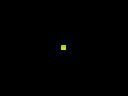

'inline_base64'

In [4]:
render_events = [event for event in events.events if event.endpoint == '/render/image']
assert render_events, 'Expected at least one render event.'
latest_render_event = render_events[0]

response_json = latest_render_event.response_json or {}
images = response_json.get('images') if isinstance(response_json, dict) else None
assert isinstance(images, list) and images, 'Render event should include images payload.'
artifact = images[0]

if artifact.get('bytes_base64'):
    png_bytes = base64.b64decode(artifact['bytes_base64'])
    display(Image(data=png_bytes))
else:
    display(HTML('<p><strong>Preview unavailable for file-path delivery.</strong></p>'))

artifact.get('delivery')


## Step 5 - Open the embedded UI and cleanup

Open the URL below in a browser while the daemon is running.


In [5]:
ui_url = f'{daemon.base_url}/ui'
stream_url = f'{daemon.base_url}/usage/events/stream?run_id={run_id}'
{'ui_url': ui_url, 'sse_url': stream_url}


{'ui_url': 'http://127.0.0.1:56052/ui',
 'sse_url': 'http://127.0.0.1:56052/usage/events/stream?run_id=nb_run_e0a618c876'}

In [6]:
daemon.stop()
'daemon stopped'


'daemon stopped'